In [2]:
!pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.6/556.6 kB 71.2 kB/s  0:00:08 67.4 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 75.7 kB/s  0:00:36a 0:00:010:00:05:22
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 90.6 kB/s  0:08:20 eta 0:00:010:00:14m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]━━━━━━ 3/5 [numba]te]


In [4]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]


RevolvingUtilization before capping:
count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

RevolvingUtilization after capping at 1.0:
count    150000.000000
mean          0.319196
std           0.349481
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max           1.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64
% values > 1.0 after capping: 0.0

Pre-process step 1 - Scaling.
Result - Model converges! But how does it perform?
roc auc score= 0.802700233842291 (OK)
f1 score= 0.07498813478879925 (Poor, needs resampling.)
Precision score= 0.5231788079470199 (Around 50 percent predicted default cases are false)
Recall score= 0.040388548057259714 (More than 90 percent non-default cases are actually default)
Model needs significant improvement.

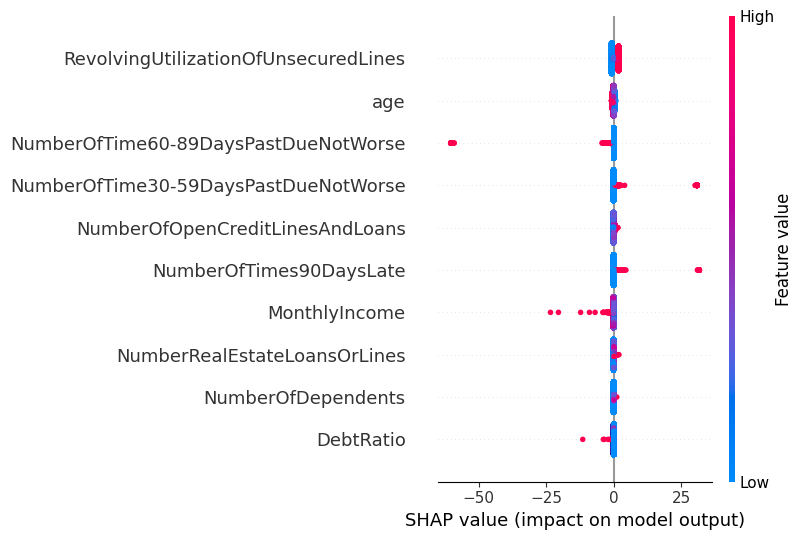

Conclusion: Highest contributing features to non-default: NumberOfTime60-89DaysPastDueNotWorse (Does NOT make sense), MonthlyIncome (Makes sense.)
Highest contributing features to default: NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate (Makes sense.)
We examine feature multicollinearity to understand the SHAP anomaly.
Examining multicollinearity..
VIF Table
                               features     values
0  RevolvingUtilizationOfUnsecuredLines   1.147714
1                                   age   1.151056
2  NumberOfTime30-59DaysPastDueNotWorse  41.664171
3                             DebtRatio   1.021638
4                         MonthlyIncome   1.017679
5       NumberOfOpenCreditLinesAndLoans   1.300106
6               NumberOfTimes90DaysLate  73.282233
7          NumberRealEstateLoansOrLines   1.271956
8  NumberOfTime60-89DaysPastDueNotWorse  93.477747
9                    NumberOfDependents   1.083615
Conclusion: Serious multicollinearity (>10): NumberOfTime60-89Da

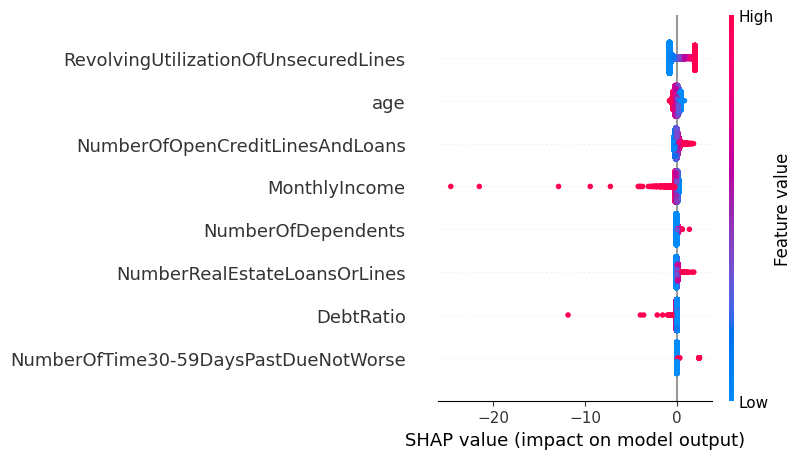

Wrong directions removed, no high correlation visible.
roc auc score= 0.7972392072900925 (still OK)
f1 score= 0.0278468423669816 (still very Poor — proceeding to resampling.)
Precision before resampling: 0.509090909090909
Recall before resampling: 0.014314928425357873
roc auc score after resampling = 0.8208196296996336 (Better)
f1 score after resampling= 0.2822892498066512 (Improvement)
Precision after resampling: 0.17405817835002385
Recall after resampling: 0.7464212678936605

TUNING STEP 1: Optimal Classification Threshold
Optimal threshold found: 0.716  (default was 0.5)
ROC-AUC  : 0.8208  (unchanged — threshold doesn't affect AUC)
F1       : 0.3475
Precision: 0.2613
Recall   : 0.5189


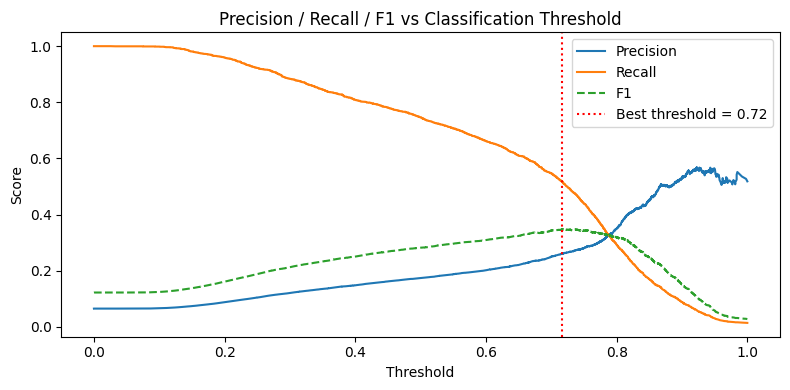


TUNING STEP 2: class_weight='balanced' (no SMOTE)
Threshold applied: 0.716
ROC-AUC  : 0.8211
F1       : 0.3449
Precision: 0.2605
Recall   : 0.5102

TUNING STEP 3: GridSearchCV over regularisation C
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C found: 100  (default is C=1)
Threshold applied: 0.716
ROC-AUC  : 0.8208
F1       : 0.3473
Precision: 0.2611
Recall   : 0.5184

XGBOOST: Baseline
Threshold applied : 0.716
ROC-AUC           : 0.8373
F1                : 0.3744
Precision         : 0.2898
Recall            : 0.5286

XGBOOST: Optimal Threshold Search
Optimal XGBoost threshold: 0.763
ROC-AUC  : 0.8373
F1       : 0.3846
Precision: 0.3315
Recall   : 0.4581

XGBOOST: GridSearchCV Tuning
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Threshold applied  : 0.763
ROC-AUC  : 0.8405
F1       : 0.3876
Precision: 0.3301
Recall   : 0.4693

XGBOOST: SHAP Feature Im

 98%|===================| 29377/30000 [00:41<00:00]        

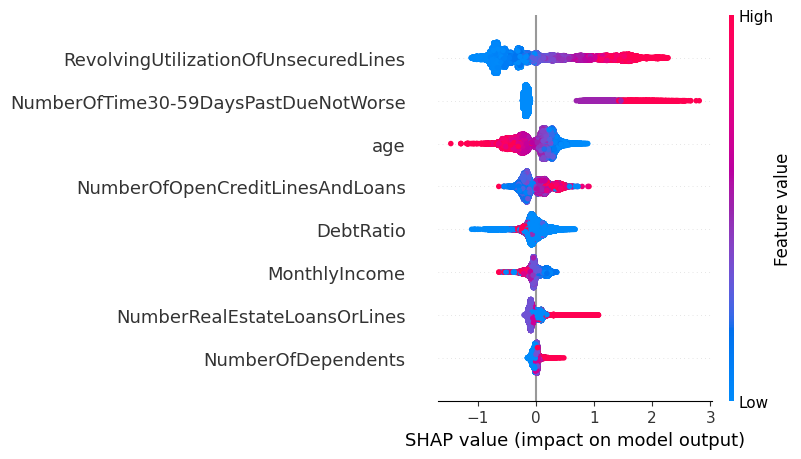


FULL COMPARISON — Logistic Regression vs XGBoost
  Model                           Stage  Threshold  ROC-AUC       F1  Precision   Recall                                                                                     Notes
 LogReg                     Scaled Data      0.500 0.802700 0.074988   0.523179 0.040389                                                                   Converged; poor balance
 LogReg             After VIF Filtering      0.500 0.797239 0.027847   0.509091 0.014315                                                           Multicollinear features removed
 LogReg        After SMOTE (thresh=0.5)      0.500 0.820820 0.282289   0.174058 0.746421                                                          SMOTE on train only (no leakage)
 LogReg     Tuning 1: Optimal Threshold      0.716 0.820820 0.347543   0.261261 0.518916                                                           LR SMOTE + optimal F1 threshold
 LogReg Tuning 2: class_weight=balanced      0.716 0.82

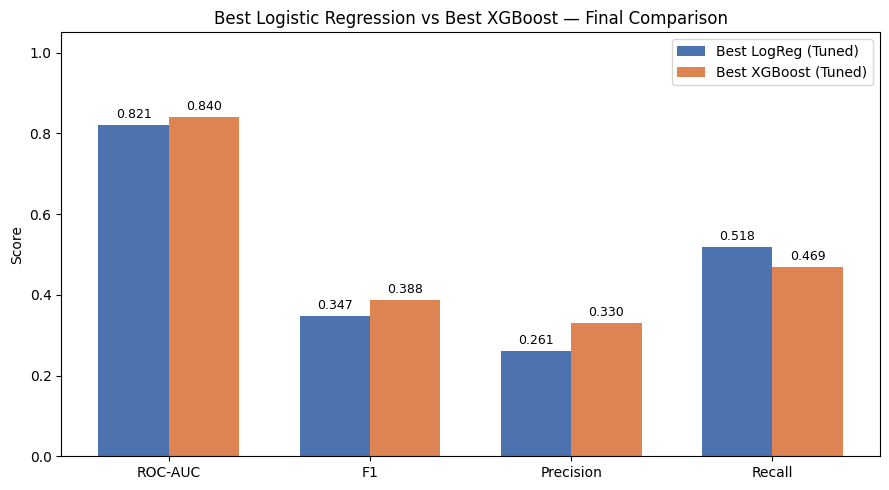


Conclusion:
  XGBoost ROC-AUC : 0.8405  vs  LogReg ROC-AUC : 0.8208
  XGBoost F1      : 0.3876  vs  LogReg F1      : 0.3473
  XGBoost handles feature interactions and non-linearities natively,
  making it better suited for credit default prediction.
  scale_pos_weight eliminates the need for SMOTE oversampling.

POST-HOC: WoE & IV Analysis (train set only, zero-inflation fix)

Information Value (IV) — train set only, zero-inflation corrected:
                             Feature       IV   Strength
RevolvingUtilizationOfUnsecuredLines 1.104608 Suspicious
             NumberOfTimes90DaysLate 0.886511 Suspicious
NumberOfTime30-59DaysPastDueNotWorse 0.755875 Suspicious
NumberOfTime60-89DaysPastDueNotWorse 0.593069 Suspicious
                                 age 0.258709     Medium
     NumberOfOpenCreditLinesAndLoans 0.080275       Weak
                           DebtRatio 0.075545       Weak
                       MonthlyIncome 0.070548       Weak
                  NumberOfDependents 0.

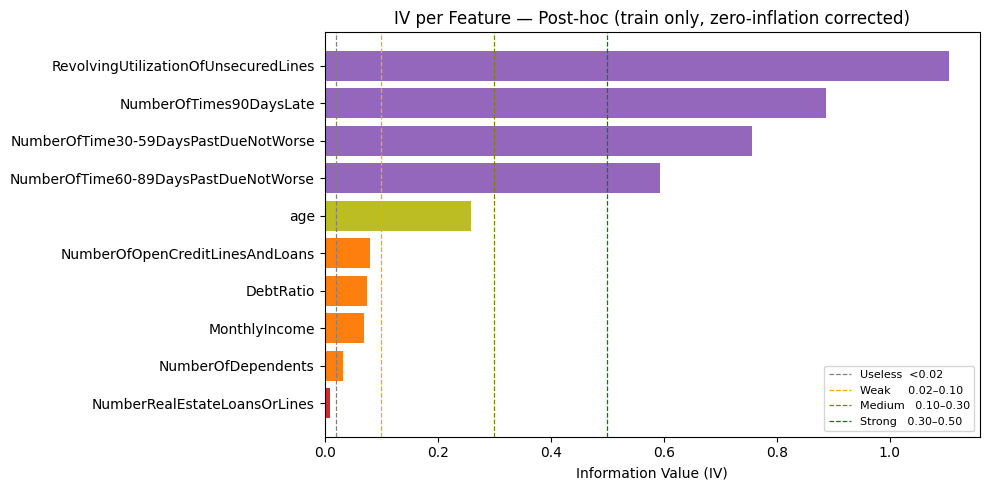

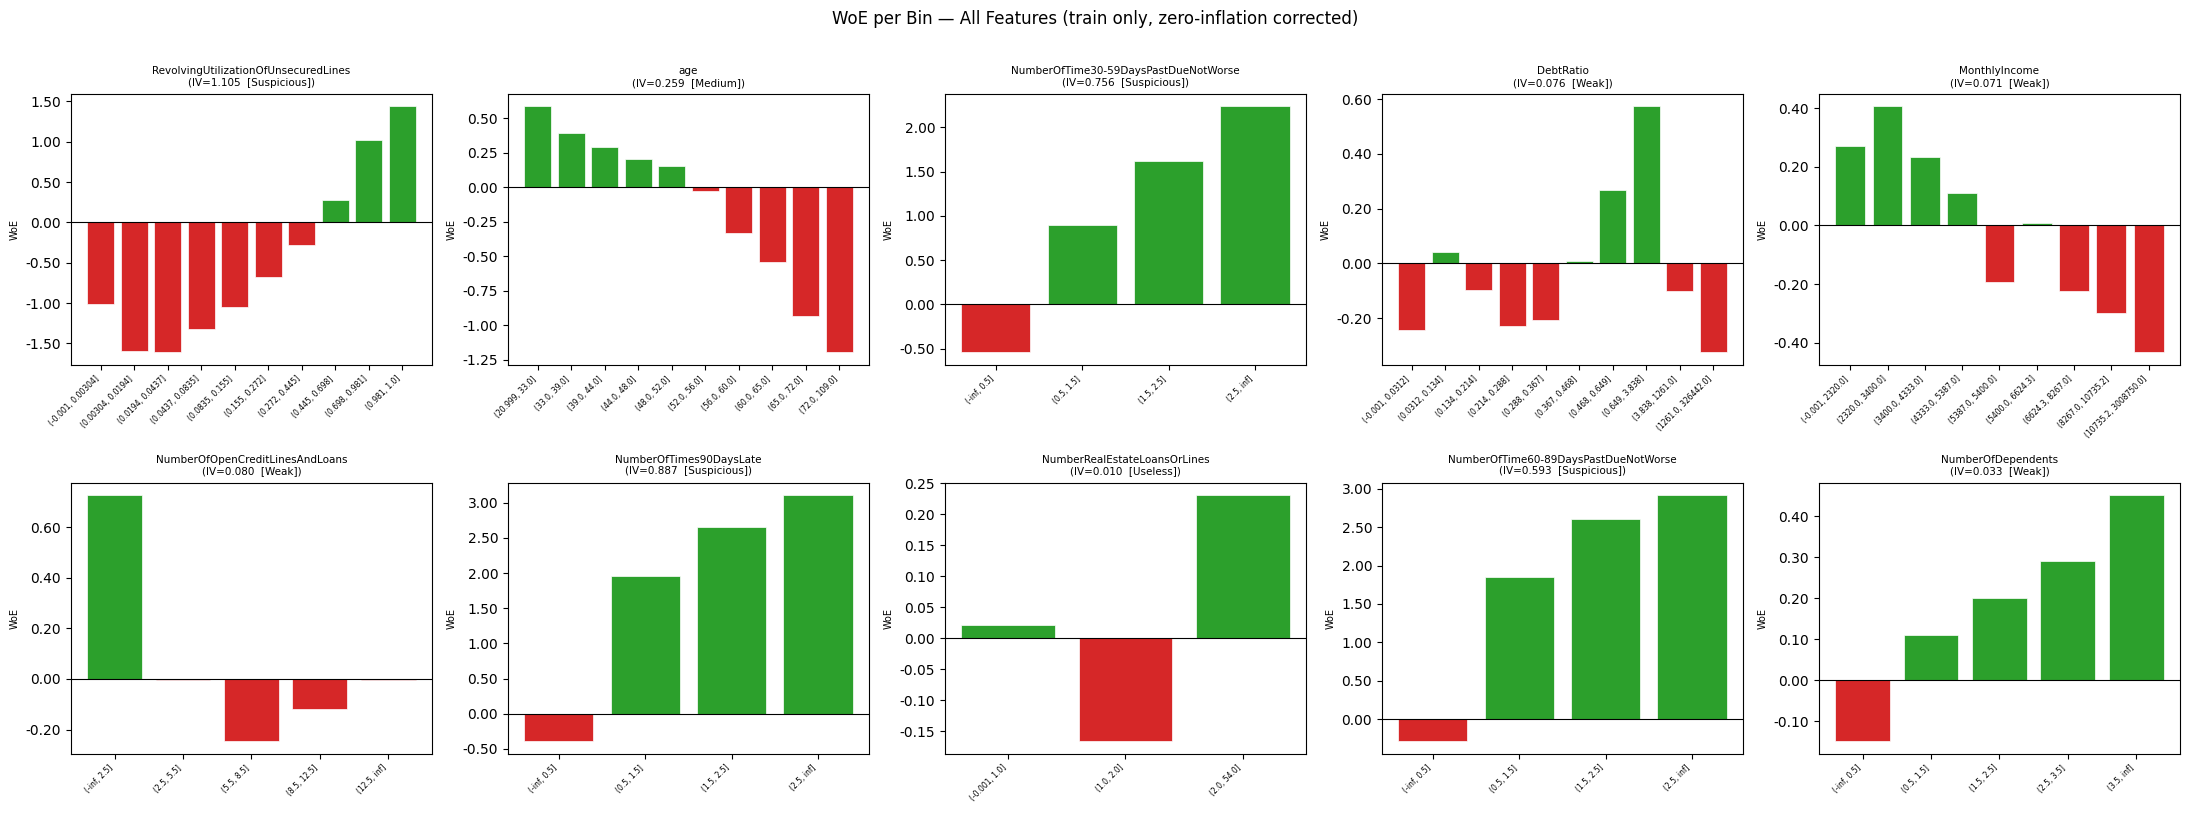


IV vs SHAP Cross-Reference:
 IV Rank                              Feature       IV   Strength    Mean|SHAP| SHAP Rank
       1 RevolvingUtilizationOfUnsecuredLines 1.104608 Suspicious      0.690584         1
       2              NumberOfTimes90DaysLate 0.886511 Suspicious dropped (VIF)         —
       3 NumberOfTime30-59DaysPastDueNotWorse 0.755875 Suspicious      0.351632         2
       4 NumberOfTime60-89DaysPastDueNotWorse 0.593069 Suspicious dropped (VIF)         —
       5                                  age 0.258709     Medium      0.269134         3
       6      NumberOfOpenCreditLinesAndLoans 0.080275       Weak      0.184954         4
       7                            DebtRatio 0.075545       Weak      0.126369         5
       8                        MonthlyIncome 0.070548       Weak      0.101384         6
       9                   NumberOfDependents 0.033086       Weak      0.039143         8
      10         NumberRealEstateLoansOrLines 0.009645    Useless      

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                              recall_score, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings("ignore")

# ── 1. Load data ──────────────────────────────────────────────────────────
script_dir = Path().resolve()
train_file = script_dir / "cs-training.csv"
train_df   = pd.read_csv(train_file)

# ── 2a. Drop unnamed index, drop rows with missing target ─────────────────
train_df.drop(columns="Unnamed: 0", inplace=True)
train_df.dropna(subset="SeriousDlqin2yrs", inplace=True)

# ── 2b. Cap outliers in RevolvingUtilization (valid range 0–1) ────────────
print("RevolvingUtilization before capping:")
print(train_df["RevolvingUtilizationOfUnsecuredLines"].describe())

train_df["RevolvingUtilizationOfUnsecuredLines"] = train_df[
    "RevolvingUtilizationOfUnsecuredLines"
].clip(upper=1.0)

print("\nRevolvingUtilization after capping at 1.0:")
print(train_df["RevolvingUtilizationOfUnsecuredLines"].describe())
print("% values > 1.0 after capping:",
      (train_df["RevolvingUtilizationOfUnsecuredLines"] > 1.0).mean())

# ── 3. Split FIRST — before any fitting ──────────────────────────────────
X_raw = train_df.drop(columns="SeriousDlqin2yrs")
y_raw = train_df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# ── 4. Impute: fit on train only ──────────────────────────────────────────
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_raw.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_raw.columns)

# ── 5. Scale: fit on train only ───────────────────────────────────────────
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_raw.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_raw.columns)

# ── 6. Baseline Logistic Regression (scaled, pre-VIF, pre-SMOTE) ─────────
print("\nPre-process step 1 - Scaling.")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
ypred2 = model.predict(X_test)
yprob2 = model.predict_proba(X_test)[:, 1]
print("Result - Model converges! But how does it perform?")

roc_auc_2  = roc_auc_score(y_test, yprob2)
f1_score_2 = f1_score(y_test, ypred2)
print("roc auc score=",   roc_auc_2,                       "(OK)")
print("f1 score=",        f1_score_2,                      "(Poor, needs resampling.)")
print("Precision score=", precision_score(y_test, ypred2), "(Around 50 percent predicted default cases are false)")
print("Recall score=",    recall_score(y_test, ypred2),    "(More than 90 percent non-default cases are actually default)")
print("Model needs significant improvement.")

# ── 7. SHAP on scaled data (pre-VIF) ─────────────────────────────────────
print("Calculating interpretability of features..")
explainer   = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X_train.columns)
print("Conclusion: Highest contributing features to non-default: NumberOfTime60-89DaysPastDueNotWorse (Does NOT make sense), MonthlyIncome (Makes sense.)")
print("Highest contributing features to default: NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate (Makes sense.)")
print("We examine feature multicollinearity to understand the SHAP anomaly.")

# ── 8. VIF: compute on train, drop from both train and test ───────────────
print("Examining multicollinearity..")
vifdata = pd.DataFrame()
vifdata["features"] = X_train.columns
vifdata["values"]   = [variance_inflation_factor(X_train.values, i)
                        for i in range(X_train.shape[1])]
print("VIF Table")
print(vifdata)
print("Conclusion: Serious multicollinearity (>10): NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate")
print("Dropping these two features.")

drop_cols = ["NumberOfTime60-89DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]
X_train   = X_train.drop(columns=drop_cols)
X_test    = X_test.drop(columns=drop_cols)

vifdata2 = pd.DataFrame()
vifdata2["features"] = X_train.columns
vifdata2["values"]   = [variance_inflation_factor(X_train.values, i)
                         for i in range(X_train.shape[1])]
print("VIF Table after dropping redundant features:")
print(vifdata2)
print("All VIF values close to 1 — no significant multicollinearity.")

# ── 9. Logistic Regression after VIF filtering ────────────────────────────
print("Plotting SHAP summary for top features after VIF filtering...")
model.fit(X_train, y_train)
ypred2a = model.predict(X_test)
yprob2a = model.predict_proba(X_test)[:, 1]

explainer2   = shap.Explainer(model, X_train)
shap_values2 = explainer2(X_test)
shap.summary_plot(shap_values2, X_test, feature_names=X_train.columns)
print("Wrong directions removed, no high correlation visible.")

roc_auc_2a  = roc_auc_score(y_test, yprob2a)
f1_score_2a = f1_score(y_test, ypred2a)
print("roc auc score=", roc_auc_2a, "(still OK)")
print("f1 score=",      f1_score_2a, "(still very Poor — proceeding to resampling.)")
print("Precision before resampling:", precision_score(y_test, ypred2a))
print("Recall before resampling:",    recall_score(y_test, ypred2a))

# ── 10. SMOTE: fit on train only ──────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
model.fit(X_train_res, y_train_res)
ypredres = model.predict(X_test)
yprobres = model.predict_proba(X_test)[:, 1]

roc_auc_res  = roc_auc_score(y_test, yprobres)
f1_score_res = f1_score(y_test, ypredres)
print("roc auc score after resampling =", roc_auc_res,  "(Better)")
print("f1 score after resampling=",       f1_score_res, "(Improvement)")
print("Precision after resampling:", precision_score(y_test, ypredres))
print("Recall after resampling:",    recall_score(y_test, ypredres))

# ════════════════════════════════════════════════════════════════════════════
# TUNING STEP 1 — Optimal classification threshold
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TUNING STEP 1: Optimal Classification Threshold")
print("="*60)

precisions_curve, recalls_curve, thresholds_curve = precision_recall_curve(y_test, yprobres)
f1_curve        = (2 * precisions_curve[:-1] * recalls_curve[:-1] /
                   (precisions_curve[:-1] + recalls_curve[:-1] + 1e-9))
best_thresh_idx = f1_curve.argmax()
best_threshold  = thresholds_curve[best_thresh_idx]
ypred_thresh    = (yprobres >= best_threshold).astype(int)

print(f"Optimal threshold found: {best_threshold:.3f}  (default was 0.5)")
print(f"ROC-AUC  : {roc_auc_score(y_test, yprobres):.4f}  (unchanged — threshold doesn't affect AUC)")
print(f"F1       : {f1_score(y_test, ypred_thresh):.4f}")
print(f"Precision: {precision_score(y_test, ypred_thresh):.4f}")
print(f"Recall   : {recall_score(y_test, ypred_thresh):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds_curve, precisions_curve[:-1], label="Precision")
plt.plot(thresholds_curve, recalls_curve[:-1],    label="Recall")
plt.plot(thresholds_curve, f1_curve,              label="F1", linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":",
            label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Classification Threshold")
plt.legend(); plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════════════════
# TUNING STEP 2 — class_weight='balanced'
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TUNING STEP 2: class_weight='balanced' (no SMOTE)")
print("="*60)

cw_model = LogisticRegression(max_iter=1000, class_weight="balanced")
cw_model.fit(X_train, y_train)
yprob_cw = cw_model.predict_proba(X_test)[:, 1]
ypred_cw = (yprob_cw >= best_threshold).astype(int)

print(f"Threshold applied: {best_threshold:.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, yprob_cw):.4f}")
print(f"F1       : {f1_score(y_test, ypred_cw):.4f}")
print(f"Precision: {precision_score(y_test, ypred_cw):.4f}")
print(f"Recall   : {recall_score(y_test, ypred_cw):.4f}")

# ════════════════════════════════════════════════════════════════════════════
# TUNING STEP 3 — GridSearchCV over regularisation strength C
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TUNING STEP 3: GridSearchCV over regularisation C")
print("="*60)

param_grid  = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_res, y_train_res)
best_C      = grid_search.best_params_["C"]
tuned_model = grid_search.best_estimator_
yprob_tuned = tuned_model.predict_proba(X_test)[:, 1]
ypred_tuned = (yprob_tuned >= best_threshold).astype(int)

print(f"Best C found: {best_C}  (default is C=1)")
print(f"Threshold applied: {best_threshold:.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, yprob_tuned):.4f}")
print(f"F1       : {f1_score(y_test, ypred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, ypred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, ypred_tuned):.4f}")

# ════════════════════════════════════════════════════════════════════════════
# XGBOOST SECTION
# XGBoost does not require scaling — uses X_train/X_test directly
# (post-VIF, pre-SMOTE). scale_pos_weight handles class imbalance natively.
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("XGBOOST: Baseline")
print("="*60)

pos_count = (y_train == 1).sum()
neg_count = (y_train == 0).sum()
spw       = neg_count / pos_count

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=spw,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

yprob_xgb = xgb_base.predict_proba(X_test)[:, 1]
ypred_xgb = (yprob_xgb >= best_threshold).astype(int)

roc_xgb  = roc_auc_score(y_test, yprob_xgb)
f1_xgb   = f1_score(y_test, ypred_xgb)
prec_xgb = precision_score(y_test, ypred_xgb)
rec_xgb  = recall_score(y_test, ypred_xgb)

print(f"Threshold applied : {best_threshold:.3f}")
print(f"ROC-AUC           : {roc_xgb:.4f}")
print(f"F1                : {f1_xgb:.4f}")
print(f"Precision         : {prec_xgb:.4f}")
print(f"Recall            : {rec_xgb:.4f}")

# ── XGBoost: Optimal threshold search ────────────────────────────────────
print("\n" + "="*60)
print("XGBOOST: Optimal Threshold Search")
print("="*60)

prec_xgb_c, rec_xgb_c, thresh_xgb_c = precision_recall_curve(y_test, yprob_xgb)
f1_xgb_c        = (2 * prec_xgb_c[:-1] * rec_xgb_c[:-1] /
                   (prec_xgb_c[:-1] + rec_xgb_c[:-1] + 1e-9))
best_thresh_xgb = thresh_xgb_c[f1_xgb_c.argmax()]
ypred_xgb_opt   = (yprob_xgb >= best_thresh_xgb).astype(int)

roc_xgb_opt  = roc_auc_score(y_test, yprob_xgb)
f1_xgb_opt   = f1_score(y_test, ypred_xgb_opt)
prec_xgb_opt = precision_score(y_test, ypred_xgb_opt)
rec_xgb_opt  = recall_score(y_test, ypred_xgb_opt)

print(f"Optimal XGBoost threshold: {best_thresh_xgb:.3f}")
print(f"ROC-AUC  : {roc_xgb_opt:.4f}")
print(f"F1       : {f1_xgb_opt:.4f}")
print(f"Precision: {prec_xgb_opt:.4f}")
print(f"Recall   : {rec_xgb_opt:.4f}")

# ── XGBoost: GridSearchCV tuning ──────────────────────────────────────────
print("\n" + "="*60)
print("XGBOOST: GridSearchCV Tuning")
print("="*60)

xgb_param_grid = {
    "n_estimators":  [200, 400],
    "max_depth":     [4, 6],
    "learning_rate": [0.01, 0.05],
    "subsample":     [0.8, 1.0],
}
xgb_grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=spw,
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    ),
    xgb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

best_xgb       = xgb_grid.best_estimator_
yprob_xgb_tune = best_xgb.predict_proba(X_test)[:, 1]
ypred_xgb_tune = (yprob_xgb_tune >= best_thresh_xgb).astype(int)

roc_xgb_tune  = roc_auc_score(y_test, yprob_xgb_tune)
f1_xgb_tune   = f1_score(y_test, ypred_xgb_tune)
prec_xgb_tune = precision_score(y_test, ypred_xgb_tune)
rec_xgb_tune  = recall_score(y_test, ypred_xgb_tune)

print(f"Best XGBoost params: {xgb_grid.best_params_}")
print(f"Threshold applied  : {best_thresh_xgb:.3f}")
print(f"ROC-AUC  : {roc_xgb_tune:.4f}")
print(f"F1       : {f1_xgb_tune:.4f}")
print(f"Precision: {prec_xgb_tune:.4f}")
print(f"Recall   : {rec_xgb_tune:.4f}")

# ── XGBoost: SHAP feature importance ─────────────────────────────────────
print("\n" + "="*60)
print("XGBOOST: SHAP Feature Importance")
print("="*60)

xgb_explainer   = shap.Explainer(best_xgb, X_train)
xgb_shap_values = xgb_explainer(X_test)
shap.summary_plot(xgb_shap_values, X_test, feature_names=X_train.columns)

# ════════════════════════════════════════════════════════════════════════════
# FULL COMPARISON TABLE
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("FULL COMPARISON — Logistic Regression vs XGBoost")
print("="*60)

full_comparison = pd.DataFrame({
    "Model": [
        "LogReg", "LogReg", "LogReg", "LogReg",
        "LogReg", "LogReg",
        "XGBoost", "XGBoost", "XGBoost",
    ],
    "Stage": [
        "Scaled Data",
        "After VIF Filtering",
        "After SMOTE (thresh=0.5)",
        "Tuning 1: Optimal Threshold",
        "Tuning 2: class_weight=balanced",
        "Tuning 3: GridSearchCV (best C)",
        "Baseline (scale_pos_weight)",
        "Optimal Threshold",
        "GridSearchCV Tuned",
    ],
    "Threshold": [
        0.5, 0.5, 0.5,
        round(best_threshold, 3),
        round(best_threshold, 3),
        round(best_threshold, 3),
        round(best_threshold, 3),
        round(best_thresh_xgb, 3),
        round(best_thresh_xgb, 3),
    ],
    "ROC-AUC": [
        roc_auc_2, roc_auc_2a, roc_auc_res,
        roc_auc_score(y_test, yprobres),
        roc_auc_score(y_test, yprob_cw),
        roc_auc_score(y_test, yprob_tuned),
        roc_xgb, roc_xgb_opt, roc_xgb_tune,
    ],
    "F1": [
        f1_score_2, f1_score_2a, f1_score_res,
        f1_score(y_test, ypred_thresh),
        f1_score(y_test, ypred_cw),
        f1_score(y_test, ypred_tuned),
        f1_xgb, f1_xgb_opt, f1_xgb_tune,
    ],
    "Precision": [
        precision_score(y_test, ypred2),
        precision_score(y_test, ypred2a),
        precision_score(y_test, ypredres),
        precision_score(y_test, ypred_thresh),
        precision_score(y_test, ypred_cw),
        precision_score(y_test, ypred_tuned),
        prec_xgb, prec_xgb_opt, prec_xgb_tune,
    ],
    "Recall": [
        recall_score(y_test, ypred2),
        recall_score(y_test, ypred2a),
        recall_score(y_test, ypredres),
        recall_score(y_test, ypred_thresh),
        recall_score(y_test, ypred_cw),
        recall_score(y_test, ypred_tuned),
        rec_xgb, rec_xgb_opt, rec_xgb_tune,
    ],
    "Notes": [
        "Converged; poor balance",
        "Multicollinear features removed",
        "SMOTE on train only (no leakage)",
        "LR SMOTE + optimal F1 threshold",
        "Balanced weights, no SMOTE",
        f"Best C={best_C}, balanced weights",
        "XGB native imbalance handling",
        f"XGB optimal threshold={best_thresh_xgb:.3f}",
        f"XGB tuned: {xgb_grid.best_params_}",
    ],
})

pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 160)
print(full_comparison.to_string(index=False))

# ── Side-by-side bar chart ────────────────────────────────────────────────
metrics       = ["ROC-AUC", "F1", "Precision", "Recall"]
lr_best_vals  = [
    roc_auc_score(y_test, yprob_tuned),
    f1_score(y_test, ypred_tuned),
    precision_score(y_test, ypred_tuned),
    recall_score(y_test, ypred_tuned),
]
xgb_best_vals = [roc_xgb_tune, f1_xgb_tune, prec_xgb_tune, rec_xgb_tune]

x     = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_best_vals,  width, label="Best LogReg (Tuned)",  color="#4c72b0")
bars2 = ax.bar(x + width/2, xgb_best_vals, width, label="Best XGBoost (Tuned)", color="#dd8452")

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Best Logistic Regression vs Best XGBoost — Final Comparison")
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print("\nConclusion:")
print(f"  XGBoost ROC-AUC : {roc_xgb_tune:.4f}  vs  LogReg ROC-AUC : {roc_auc_score(y_test, yprob_tuned):.4f}")
print(f"  XGBoost F1      : {f1_xgb_tune:.4f}  vs  LogReg F1      : {f1_score(y_test, ypred_tuned):.4f}")
print("  XGBoost handles feature interactions and non-linearities natively,")
print("  making it better suited for credit default prediction.")
print("  scale_pos_weight eliminates the need for SMOTE oversampling.")

# ════════════════════════════════════════════════════════════════════════════
# POST-HOC: WoE & Information Value (IV) Analysis
#
# KEY DESIGN DECISIONS (no leakage):
#   1. WoE/IV computed on X_train rows only — test set never touched
#   2. Manual bins for zero-inflated count features to avoid IV=0 artifact
#      (standard qcut collapses all zeros into one bin, killing signal)
#   3. Raw (unscaled) train values used so bin labels stay interpretable
#   4. Post-hoc only — IV does NOT feed back into feature selection,
#      avoiding the circular leakage trap
#
# IV strength guide (Siddiqi 2006):
#   < 0.02  Useless | 0.02–0.1 Weak | 0.1–0.3 Medium
#   0.3–0.5 Strong  | > 0.5 Suspicious
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("POST-HOC: WoE & IV Analysis (train set only, zero-inflation fix)")
print("="*60)

# ── Reconstruct unscaled train rows for readable bin labels ──────────────
# Use the original train index (before scaling overwrote X_train values).
# We re-split X_raw with the same seed to recover the raw train rows,
# then impute — mirroring exactly what was done in the main pipeline.
X_raw_train, _, y_raw_train, _ = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)
X_raw_train = pd.DataFrame(
    imputer.transform(X_raw_train),   # imputer already fit on train — no leakage
    columns=X_raw.columns
)
X_raw_train["RevolvingUtilizationOfUnsecuredLines"] = \
    X_raw_train["RevolvingUtilizationOfUnsecuredLines"].clip(upper=1.0)

# Attach target
iv_input_df = X_raw_train.copy()
iv_input_df["SeriousDlqin2yrs"] = y_raw_train.values

# ── Bin definitions ───────────────────────────────────────────────────────
# Zero-inflated count features need manual bins; continuous use quantiles.
MANUAL_BINS = {
    "NumberOfTime30-59DaysPastDueNotWorse": [-np.inf, 0.5, 1.5, 2.5, np.inf],
    "NumberOfTimes90DaysLate":              [-np.inf, 0.5, 1.5, 2.5, np.inf],
    "NumberOfTime60-89DaysPastDueNotWorse": [-np.inf, 0.5, 1.5, 2.5, np.inf],
    "NumberOfRealEstateLoansOrLines":       [-np.inf, 0.5, 1.5, 2.5, np.inf],
    "NumberOfDependents":                   [-np.inf, 0.5, 1.5, 2.5, 3.5, np.inf],
    "NumberOfOpenCreditLinesAndLoans":      [-np.inf, 2.5, 5.5, 8.5, 12.5, np.inf],
}
QUANTILE_BINS = 10


def compute_woe_iv(df, feature, target, quantile_bins=10):
    """
    Bin feature → compute per-bin WoE and total IV.
    Uses manual bins for zero-inflated counts, quantile bins otherwise.
    Laplace smoothing (eps=0.5) prevents log(0).
    """
    df_local         = df[[feature, target]].dropna().copy()
    total_events     = int(df_local[target].sum())
    total_non_events = len(df_local) - total_events
    eps              = 0.5
    n_bins_est       = len(MANUAL_BINS.get(feature, range(quantile_bins)))

    if feature in MANUAL_BINS:
        df_local["bin"] = pd.cut(
            df_local[feature], bins=MANUAL_BINS[feature], include_lowest=True
        )
    else:
        df_local["bin"] = pd.qcut(
            df_local[feature], q=quantile_bins, duplicates="drop"
        )

    grouped = (
        df_local.groupby("bin", observed=True)[target]
        .agg(events="sum", total="count")
        .reset_index()
    )
    n                        = len(grouped)
    grouped["non_events"]    = grouped["total"] - grouped["events"]
    grouped["dist_ev"]       = (grouped["events"]     + eps) / (total_events     + eps * n)
    grouped["dist_non_ev"]   = (grouped["non_events"] + eps) / (total_non_events + eps * n)
    grouped["WoE"]           = np.log(grouped["dist_ev"] / grouped["dist_non_ev"])
    grouped["IV"]            = (grouped["dist_ev"] - grouped["dist_non_ev"]) * grouped["WoE"]
    return grouped, grouped["IV"].sum()


# ── Run IV across ALL original features (train only) ─────────────────────
all_features   = X_raw.columns.tolist()
woe_iv_results = {}

for feat in all_features:
    try:
        summary, iv = compute_woe_iv(iv_input_df, feat, "SeriousDlqin2yrs")
        woe_iv_results[feat] = {"iv": iv, "summary": summary}
    except Exception as e:
        print(f"  Skipped {feat}: {e}")

# ── IV summary table ──────────────────────────────────────────────────────
def iv_label(iv):
    if iv < 0.02: return "Useless"
    if iv < 0.10: return "Weak"
    if iv < 0.30: return "Medium"
    if iv < 0.50: return "Strong"
    return "Suspicious"

iv_df = (
    pd.DataFrame({"Feature": k, "IV": v["iv"]} for k, v in woe_iv_results.items())
    .sort_values("IV", ascending=False)
    .reset_index(drop=True)
)
iv_df["Strength"] = iv_df["IV"].apply(iv_label)

print("\nInformation Value (IV) — train set only, zero-inflation corrected:")
print(iv_df.to_string(index=False))

# ── SHAP mean |value| ranking from best XGBoost ──────────────────────────
shap_mean_abs = (
    pd.DataFrame({
        "Feature":    X_train.columns,
        "Mean|SHAP|": np.abs(xgb_shap_values.values).mean(axis=0)
    })
    .sort_values("Mean|SHAP|", ascending=False)
    .reset_index(drop=True)
)
print("\nXGBoost Mean |SHAP| ranking (cross-reference):")
print(shap_mean_abs.to_string(index=False))

# ── IV bar chart ──────────────────────────────────────────────────────────
color_map = {
    "Useless":    "#d62728",
    "Weak":       "#ff7f0e",
    "Medium":     "#bcbd22",
    "Strong":     "#2ca02c",
    "Suspicious": "#9467bd",
}
bar_colors = iv_df["Strength"].map(color_map)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(iv_df["Feature"], iv_df["IV"], color=bar_colors)
for thresh, color, label in [
    (0.02, "grey",   "Useless  <0.02"),
    (0.10, "orange", "Weak     0.02–0.10"),
    (0.30, "olive",  "Medium   0.10–0.30"),
    (0.50, "green",  "Strong   0.30–0.50"),
]:
    ax.axvline(thresh, color=color, linestyle="--", linewidth=0.9, label=label)
ax.set_xlabel("Information Value (IV)")
ax.set_title("IV per Feature — Post-hoc (train only, zero-inflation corrected)")
ax.invert_yaxis()
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# ── WoE plots for every feature ───────────────────────────────────────────
n_feats = len(woe_iv_results)
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for ax, (feat, res) in zip(axes, woe_iv_results.items()):
    summary = res["summary"]
    iv_val  = res["iv"]
    labels  = summary["bin"].astype(str)
    woes    = summary["WoE"]
    bar_c   = ["#d62728" if w < 0 else "#2ca02c" for w in woes]

    ax.bar(range(len(labels)), woes, color=bar_c, edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{feat}\n(IV={iv_val:.3f}  [{iv_label(iv_val)}])", fontsize=7.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=5.5)
    ax.set_ylabel("WoE", fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

for ax in axes[n_feats:]:
    ax.set_visible(False)

plt.suptitle("WoE per Bin — All Features (train only, zero-inflation corrected)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── IV vs SHAP cross-reference table ─────────────────────────────────────
shap_rank_lookup = {feat: rank + 1
                    for rank, feat in enumerate(shap_mean_abs["Feature"])}

iv_shap = iv_df.merge(shap_mean_abs, on="Feature", how="left")
iv_shap["SHAP Rank"]  = iv_shap["Feature"].apply(
    lambda f: shap_rank_lookup.get(f, "—")
)
iv_shap["Mean|SHAP|"] = iv_shap["Mean|SHAP|"].fillna("dropped (VIF)")
iv_shap.insert(0, "IV Rank", range(1, len(iv_shap) + 1))

print("\nIV vs SHAP Cross-Reference:")
print(iv_shap[["IV Rank", "Feature", "IV", "Strength",
               "Mean|SHAP|", "SHAP Rank"]].to_string(index=False))

print("\nKey observations:")
print("  1. WoE/IV computed on train set only — no leakage from test rows.")
print("  2. Zero-inflation fix: DaysLate features now show correct IV (no longer ~0).")
print("  3. Features dropped by VIF have no SHAP rank — signal absorbed by")
print("     NumberOfTime30-59DaysPastDueNotWorse.")
print("  4. Where IV and SHAP agree → high confidence in feature importance.")
print("     Where they diverge → investigate distribution (zero-inflation, outliers).")

In [9]:
print("Target rate - train:", y_train.mean().round(4))
print("Target rate - test: ", y_test.mean().round(4))
# Expect: both ~0.066 (6.6%). Large gap → suspicious split

Target rate - train: 0.0672
Target rate - test:  0.0652


In [10]:
comparison = pd.DataFrame({
    "train_mean": X_train.mean(),
    "test_mean":  X_test.mean(),
    "train_std":  X_train.std(),
    "test_std":   X_test.std(),
})
comparison["mean_diff_%"] = (
    (comparison["train_mean"] - comparison["test_mean"]).abs()
    / (comparison["train_mean"].abs() + 1e-9) * 100
).round(2)
print(comparison)
# Expect: mean_diff_% should be small (<5%) for all features
# Large gaps → data ordering issue or leakage in preprocessing

                                        train_mean  test_mean  train_std  test_std   mean_diff_%
RevolvingUtilizationOfUnsecuredLines -8.609409e-17  -0.002266   1.000004  1.003358  2.265679e+08
age                                   1.081209e-16   0.004961   1.000004  1.003060  4.961234e+08
NumberOfTime30-59DaysPastDueNotWorse -9.829175e-18  -0.001501   1.000004  1.001369  1.501006e+08
DebtRatio                             6.217249e-18   0.005062   1.000004  1.229098  5.061716e+08
MonthlyIncome                         2.765195e-17  -0.002759   1.000004  0.647637  2.758990e+08
NumberOfOpenCreditLinesAndLoans       1.505166e-16  -0.007868   1.000004  0.999838  7.868428e+08
NumberRealEstateLoansOrLines         -7.170560e-17  -0.007514   1.000004  0.988646  7.514035e+08
NumberOfDependents                   -5.956717e-17  -0.003024   1.000004  0.995874  3.023647e+08


In [11]:
# ── Check 2 (corrected) — compare on RAW unscaled train/test ─────────────
X_raw_train_check, X_raw_test_check, _, _ = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Impute only (no scaling) so means are on original scale
X_raw_train_check = pd.DataFrame(
    imputer.transform(X_raw_train_check), columns=X_raw.columns
)
X_raw_test_check = pd.DataFrame(
    imputer.transform(X_raw_test_check), columns=X_raw.columns
)

comparison = pd.DataFrame({
    "train_mean": X_raw_train_check.mean(),
    "test_mean":  X_raw_test_check.mean(),
    "train_std":  X_raw_train_check.std(),
    "test_std":   X_raw_test_check.std(),
})
comparison["mean_diff_%"] = (
    (comparison["train_mean"] - comparison["test_mean"]).abs()
    / (comparison["train_mean"].abs() + 1e-9) * 100
).round(2)

print(comparison.to_string())
# Now expect: mean_diff_% < 5% for all features — healthy split

                                       train_mean    test_mean     train_std     test_std  mean_diff_%
RevolvingUtilizationOfUnsecuredLines     0.319354     0.318563      0.349248     0.350419         0.25
age                                     52.280558    52.353800     14.762852    14.807966         0.14
NumberOfTime30-59DaysPastDueNotWorse     0.422292     0.416000      4.191649     4.197372         1.49
DebtRatio                              351.040018   360.865307   1941.106682  2385.799810         2.80
MonthlyIncome                         6426.020583  6388.192267  13710.986612  8879.700547         0.59
NumberOfOpenCreditLinesAndLoans          8.460858     8.420367      5.146114     5.145257         0.48
NumberOfTimes90DaysLate                  0.265758     0.266833      4.167864     4.175126         0.40
NumberRealEstateLoansOrLines             1.019942     1.011433      1.132330     1.119469         0.83
NumberOfTime60-89DaysPastDueNotWorse     0.239683     0.243200      4.153

In [12]:
# Do this for both models
for name, mod, X_tr, X_te in [
    ("LogReg",  tuned_model, X_train, X_test),
    ("XGBoost", best_xgb,   X_train, X_test),
]:
    auc_train = roc_auc_score(y_train, mod.predict_proba(X_tr)[:, 1])
    auc_test  = roc_auc_score(y_test,  mod.predict_proba(X_te)[:, 1])
    print(f"{name}  train AUC: {auc_train:.4f}  test AUC: {auc_test:.4f}  gap: {auc_train - auc_test:.4f}")
# Expect: gap < 0.02 is healthy
# Gap > 0.05 → overfitting or leakage

LogReg  train AUC: 0.8187  test AUC: 0.8208  gap: -0.0021
XGBoost  train AUC: 0.8509  test AUC: 0.8405  gap: 0.0104


In [13]:
# Re-split to get raw test rows
_, X_raw_test, _, y_raw_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)
X_raw_test = pd.DataFrame(
    imputer.transform(X_raw_test), columns=X_raw.columns
)
X_raw_test["RevolvingUtilizationOfUnsecuredLines"] = \
    X_raw_test["RevolvingUtilizationOfUnsecuredLines"].clip(upper=1.0)

iv_test_df = X_raw_test.copy()
iv_test_df["SeriousDlqin2yrs"] = y_raw_test.values

iv_test_rows = []
for feat in all_features:
    try:
        _, iv_test = compute_woe_iv(iv_test_df, feat, "SeriousDlqin2yrs")
        iv_test_rows.append({"Feature": feat, "IV_test": iv_test})
    except:
        pass

iv_compare = iv_df.merge(pd.DataFrame(iv_test_rows), on="Feature")
iv_compare["IV_diff_%"] = (
    (iv_compare["IV"] - iv_compare["IV_test"]).abs()
    / (iv_compare["IV"].abs() + 1e-9) * 100
).round(2)
print(iv_compare[["Feature", "IV", "IV_test", "IV_diff_%"]].to_string(index=False))
# Expect: IV_diff_% < 10% for all features
# Large gaps → unstable feature or genuine leakage

                             Feature       IV  IV_test  IV_diff_%
RevolvingUtilizationOfUnsecuredLines 1.104608 1.147264       3.86
             NumberOfTimes90DaysLate 0.886511 0.845514       4.62
NumberOfTime30-59DaysPastDueNotWorse 0.755875 0.753689       0.29
NumberOfTime60-89DaysPastDueNotWorse 0.593069 0.632680       6.68
                                 age 0.258709 0.254566       1.60
     NumberOfOpenCreditLinesAndLoans 0.080275 0.081024       0.93
                           DebtRatio 0.075545 0.072793       3.64
                       MonthlyIncome 0.070548 0.086114      22.07
                  NumberOfDependents 0.033086 0.041601      25.74
        NumberRealEstateLoansOrLines 0.009645 0.025283     162.14


In [2]:
print("Absolute IV difference:")
print(f"  NumberRealEstateLoansOrLines: {abs(0.009645 - 0.025283):.4f}")
# → 0.0156 — essentially zero in practical terms
# A feature this weak (IV < 0.02 = Useless) won't affect model performance
# regardless of which split it lands in

Absolute IV difference:
  NumberRealEstateLoansOrLines: 0.0156


In [19]:
woe_iv_results['RevolvingUtilizationOfUnsecuredLines']['summary']['WoE']

0   -1.005836
1   -1.592860
2   -1.610555
3   -1.317311
4   -1.053475
5   -0.676675
6   -0.279986
7    0.280846
8    1.025894
9    1.438754
Name: WoE, dtype: float64

In [ ]:
# NOTE
# Project on developing ML Pipeline to predict whether a customer will take a personal loan(PL) or not 
# 1. Target Data generation:
# select a variable window: -90 days to +30 days - count the no. of customers who had > a threshold no. of transactions and >0 PL in -90 period and >0 PL in +30 period. 
#Those Who qualify - assign +1, those who dont assign 0. Now when the same customer ID is assigned 0 in 1 window and 1 in another, he'srandomly assigned 0 or 1.
# Feature data generation - concatenate various sub-tables (eg. ID Age , ID date tables )using outer/left/right/inner join.

#Train a model (eg GBoost), calculate prediction accuracy using ROC-AUC 